In [1]:
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN, MSE, refined_MSE, MSE, log_stirling
import torch
#from fastPLNmodels.models import IMPS_PLN, log_likelihood, fastPLN, fastPLNPCA, PLNmodel
from pyPLNmodels.models import IMPS_PLN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time 

Device  cpu


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 
torch.cuda.is_available()

False

In [3]:
%load_ext autoreload

%autoreload 2

In [4]:
d = 2
n = 100;  p = 30
q = 3


In [5]:
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device )*0.75
covariates = torch.randn((n,d), device = device)/1
O =  1+torch.zeros((n,p), device = device)
Y, Z,_  = sample_PLN(true_C,true_beta, O, covariates)

In [6]:
Y.max()

tensor(302.)

<AxesSubplot:>

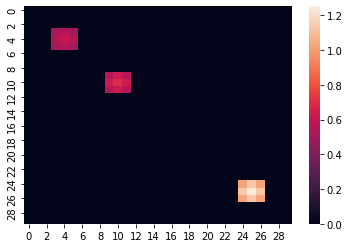

In [7]:
sns.heatmap((true_C@(true_C.T)).cpu())

In [8]:
mypln = IMPS_PLN(q=q)
mypln.fit(Y,O,covariates)

Intialization ...
Initalization done


  0%|          | 0/500 [00:00<?, ?it/s]

size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
en

  0%|          | 1/500 [00:00<01:40,  4.97it/s]

size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
en

...

size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
en

 15%|█▍        | 73/500 [00:07<00:42, 10.02it/s]

size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
end torch.Size([40, 30, 1])
size W torch.Size([40, 3])
first torch.Size([1, 30, 3])
second torch.Size([40, 3, 1])
en

 15%|█▍        | 74/500 [00:07<00:45,  9.31it/s]

size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
end torch.Size([20, 30, 1])
size W torch.Size([20, 3])
first torch.Size([1, 30, 3])
second torch.Size([20, 3, 1])
en

Device  cpu
Best likelihood:  -68.83256862661136
len log_list 75
len runtime 75


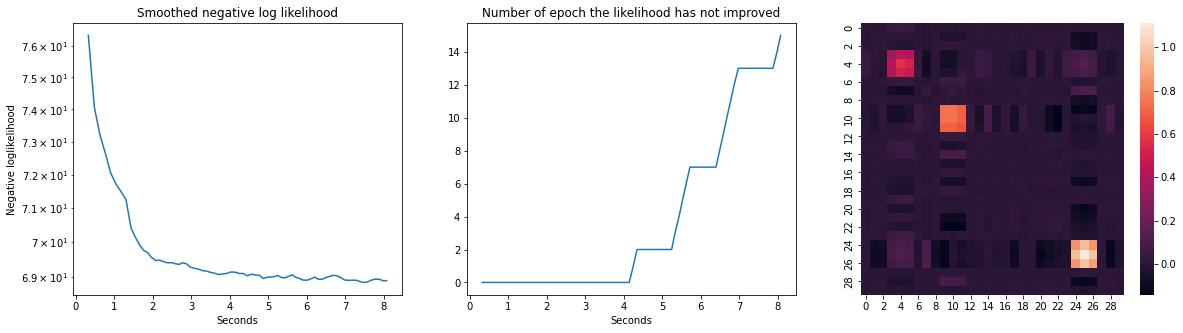

<Figure size 432x288 with 0 Axes>

In [14]:
print(mypln)